# Part 1: Introduction

For our final project, we analyzed [Smart Home Energy Consumption dataset](https://www.kaggle.com/datasets/adilshamim8/smart-home-energy-consumption)
from Kaggle to understand the key factors driving energy costs in residential settings. The dataset contains over 50,000 records of device-level energy usage across various smart appliances, including power consumption, usage duration, environmental conditions, and associated energy costs.

* This topic is especially timely given today’s energy challenges:

* U.S. residential electricity prices have risen by over 20\% in the past five years (EIA, 2023).

* Buildings account for 40\% of global energy consumption (IEA).

* The global shipment of smart home devices reached around 892 million units in 2024.

With energy prices rising, sustainability goals intensifying, and smart home adoption accelerating, we wanted to understand how household devices impact energy use. By leveraging both supervised and unsupervised machine learning techniques, we aimed to identify the most significant predictors of energy costs and develop  models for forecasting household energy cost.

Throughout our analysis, we employed a comprehensive approach that included exploratory data analysis, feature engineering, hypothesis testing, PCA, unsupervised clustering, and predictive modeling with linear regression and ensemble methods. For each stage of analysis, we carefully documented our methodology, findings, and interpretations to build a holistic understanding of residential smarthome device energy consumption dynamics.

# Part 2: Data Loading & Preprocessing

We imported the relevant libraries for all stages of our report (pre-processing, exploratory data analysis, and model selection). This includes fundamental libraries such as pandas, matplotlib, numpy, and sklearn.

In [ ]:
# Imports + Installs
!pip install category_encoders
!pip install pandasql
import pandas as pd
import seaborn as sns
import dask.dataframe as dd
import matplotlib.pyplot as plt
import folium
import numpy as np
import category_encoders as ce
import dask.array as da
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import tqdm
import copy
import pandasql as ps
from xgboost import XGBRegressor
from folium.plugins import HeatMap
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from sklearn import datasets, linear_model
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from torch.utils import data as data_utils
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=18032ea7164b4295d74e5c92fa64f46696e73b47566b5f8a1b3d03947ebd837b
  Stored in directory: /root/.cache/pip/wheels/68/5d/a5/edc271b998f909801d7956959f699b976cc9896075dc47c153
Successfully built pandasql


## 2.1 Loading + Preprocessing

To expedite processing capabilities, we decided to use the [Dask library](https://docs.dask.org/en/stable/). The original dataset is derived from an existing resource available on Kaggle [(Smart Home Energy Consumption)](https://www.kaggle.com/datasets/adilshamim8/smart-home-energy-consumption).

### 2.1.1 Loading Data & Converting to Dataframe

We mount Google Drive to access our Kaggle credentials, download the smart home energy dataset, and extract the CSV file. We load the data into a pandas DataFrame (smart_df) for initial processing and then convert it into a Dask DataFrame (smart_ddf) to leverage parallelism and multi-core CPUs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
# Read the uploaded kaggle.json file
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [ ]:
#!/bin/bash
!kaggle datasets download adilshamim8/smart-home-energy-consumption

Dataset URL: https://www.kaggle.com/datasets/adilshamim8/smart-home-energy-consumption
License(s): other


In [ ]:
# Unzip folder in Colab content folder
!unzip /content/smart-home-energy-consumption.zip

Archive:  /content/smart-home-energy-consumption.zip
  inflating: smart_home_energy_consumption.csv  


In [ ]:
smart_df = pd.read_csv('smart_home_energy_consumption.csv')

In [ ]:
# Convert to Dask dataframe from Pandas dataframe
smart_ddf = dd.from_pandas(smart_df, npartitions=10)

### 2.1.2 Analyzing Data Structure

To better understand how our data is distributed, we calculated key measures of central tendency and variability.

In [ ]:
# Dataframe descriptive statistics
smart_ddf.describe().compute()

,Power Consumption (W),Temperature (°C),Humidity (%),Usage Duration (minutes),Energy Cost ($)
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,570.842000,22.499879,54.993893,90.418140,103.312700
std,743.596529,4.321193,14.469001,51.659167,165.772992
min,2.500000,15.000000,30.000000,1.000000,0.010000
25%,53.442500,18.967500,42.810000,47.000000,4.635000
50%,144.400000,22.635000,55.545000,91.000000,24.085000
75%,1069.197500,26.360000,67.822500,137.000000,138.545000
max,2999.710000,30.000000,80.000000,179.000000,1041.140000


The results indicated a few noticeable takeaways:

*   The average power consumption per device usage was 571 W, but the distribution was heavily skewed. While 50% of usage events consumed less than 144 W, the upper quartile jumped to over 1069 W, with a maximum nearing 3000 W. This suggests a wide range of device types in the dataset—from small electronics (like smart bulbs) to high-power appliances (such as heaters or air conditioners).
*   Weather conditions, captured through indoor temperature and humidity readings, reflected generally comfortable environments, with an average temperature of 22.5°C and average humidity at 55%. However, temperature ranged from 15°C to 30°C, and humidity from 30% to 80%, indicating notable variance across homes or seasons. We may be interested in how environmental factors influence energy usage,
*   The average device usage duration was approximately 90 minutes, with some sessions extending up to nearly 3 hours. However, 25% of device activations lasted under 47 minutes. Note that energy cost is dependent on the usage duration and power consumption.

In [ ]:
# Dataframe column datatypes
smart_df.dtypes

,0
Timestamp,object
Device ID,object
Device Type,object
Power Consumption (W),float64
Room Location,object
Temperature (°C),float64
Humidity (%),float64
Usage Duration (minutes),int64
Energy Cost ($),float64
On/Off Status,object


In [ ]:
# First 10 tuples of data
smart_ddf.head(10)

,Timestamp,Device ID,Device Type,Power Consumption (W),Room Location,Temperature (°C),Humidity (%),Usage Duration (minutes),Energy Cost ($),On/Off Status
0,2024-03-25 16:38:00,D-1860,Washing Machine,341.72,Garage,23.95,52.29,75,51.26,On
1,2024-05-01 16:03:00,D-9322,Laptop Charger,31.24,Bedroom,25.83,76.93,130,8.12,On
2,2024-06-12 17:56:00,D-5555,Smart Bulb,11.12,Garage,21.48,44.56,59,1.31,On
3,2024-04-13 19:43:00,D-2899,Heater,2028.47,Living Room,15.70,60.38,21,85.20,On
4,2024-08-30 16:17:00,D-9792,Washing Machine,732.82,Bedroom,20.78,30.80,130,190.53,On
5,2024-06-27 03:08:00,D-9226,Laptop Charger,84.56,Bathroom,17.73,67.77,134,22.66,On
6,2024-08-06 20:19:00,D-7873,TV,94.98,Bedroom,28.42,59.89,48,9.12,On
7,2024-09-02 12:11:00,D-8869,Smart Plug,4.13,Garage,19.07,71.44,154,1.27,Off
8,2024-10-27 05:15:00,D-6276,Smart Plug,6.51,Living Room,15.23,51.17,129,1.68,On
9,2024-04-04 16:10:00,D-7736,Heater,2422.68,Kitchen,26.57,33.70,41,198.66,Off


In [ ]:
# Unique values for device type
smart_ddf['Device Type'].unique().compute()

,Device Type
0,Heater
0,TV
1,Air Conditioner
0,Ceiling Fan
1,Refrigerator
0,Microwave
0,Laptop Charger
0,Smart Bulb
0,Washing Machine
1,Smart Plug


In [ ]:
# Unique values for room location
smart_ddf['Room Location'].unique().compute()

,Room Location
0,Kitchen
0,Bedroom
1,Living Room
0,Office
0,Bathroom
0,Garage


In [ ]:
# Number of unique values for device id
smart_ddf['Device ID'].nunique().compute()

np.int64(8956)

### 2.1.3 Initial Feature Engineering


To capture potential time-based effects, we also extract Hour, DayOfWeek, and Month from the timestamp.


Calculating Cost Per Min: We create a new feature by dividing total energy cost by usage duration. In real-world energy systems, utilities often use Time-of-Use (TOU) pricing, where costs vary by time of day and day of the week due to shifting demand. Normalizing cost this way allows us to investigate whether energy prices in our dataset reflect these TOU patterns.



In [ ]:
smart_ddf['Timestamp_dt'] = dd.to_datetime(smart_ddf['Timestamp'])

In [ ]:
if 'Timestamp_dt' in smart_ddf.columns:
    # Extract time components
    smart_ddf['Hour'] = smart_ddf['Timestamp_dt'].dt.hour
    smart_ddf['DayOfWeek'] = smart_ddf['Timestamp_dt'].dt.dayofweek
    smart_ddf['Month'] = smart_ddf['Timestamp_dt'].dt.month

In [ ]:
smart_ddf['Cost Per Min'] = smart_ddf['Energy Cost ($)']/smart_ddf['Usage Duration (minutes)']

### 2.1.4 Dropping Null Rows

In [ ]:
# Drop all rows with null values
smart_ddf.dropna()

,Timestamp,Device ID,Device Type,Power Consumption (W),Room Location,Temperature (°C),Humidity (%),Usage Duration (minutes),Energy Cost ($),On/Off Status,Timestamp_dt,Hour,DayOfWeek,Month,Cost Per Min
npartitions=10,,,,,,,,,,,,,,,
0,string,string,string,float64,string,float64,float64,float64,float64,string,datetime64[ns],int32,int32,int32,float64
5000,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45000,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49999,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [ ]:
# Convert back to Pandas
smart_df = smart_ddf.compute()

In [ ]:
print(smart_df.head())
print(smart_df.info())

             Timestamp Device ID      Device Type  Power Consumption (W)  \
0  2024-03-25 16:38:00    D-1860  Washing Machine                 341.72   
1  2024-05-01 16:03:00    D-9322   Laptop Charger                  31.24   
2  2024-06-12 17:56:00    D-5555       Smart Bulb                  11.12   
3  2024-04-13 19:43:00    D-2899           Heater                2028.47   
4  2024-08-30 16:17:00    D-9792  Washing Machine                 732.82   

  Room Location  Temperature (°C)  Humidity (%)  Usage Duration (minutes)  \
0        Garage             23.95         52.29                        75   
1       Bedroom             25.83         76.93                       130   
2        Garage             21.48         44.56                        59   
3   Living Room             15.70         60.38                        21   
4       Bedroom             20.78         30.80                       130   

   Energy Cost ($) On/Off Status        Timestamp_dt  Hour  DayOfWeek  Month  \


In [ ]:
# Checking for rows with 0 minutes of usage
smart_df[smart_df['Usage Duration (minutes)'] == 0]

,Timestamp,Device ID,Device Type,Power Consumption (W),Room Location,Temperature (°C),Humidity (%),Usage Duration (minutes),Energy Cost ($),On/Off Status,Timestamp_dt,Hour,DayOfWeek,Month,Cost Per Min


# Part 3: Exploratory Data Analysis

After creating summary statistics and understanding the distribution of our data, we decided to further our understanding by evaluating the relationships between meaningful combinations of features. The selection of such combinations was at our discretion, but each combination felt intuitively important -- both from a statistical sense, but also when developing our model.

## 3.0 Outlier Check

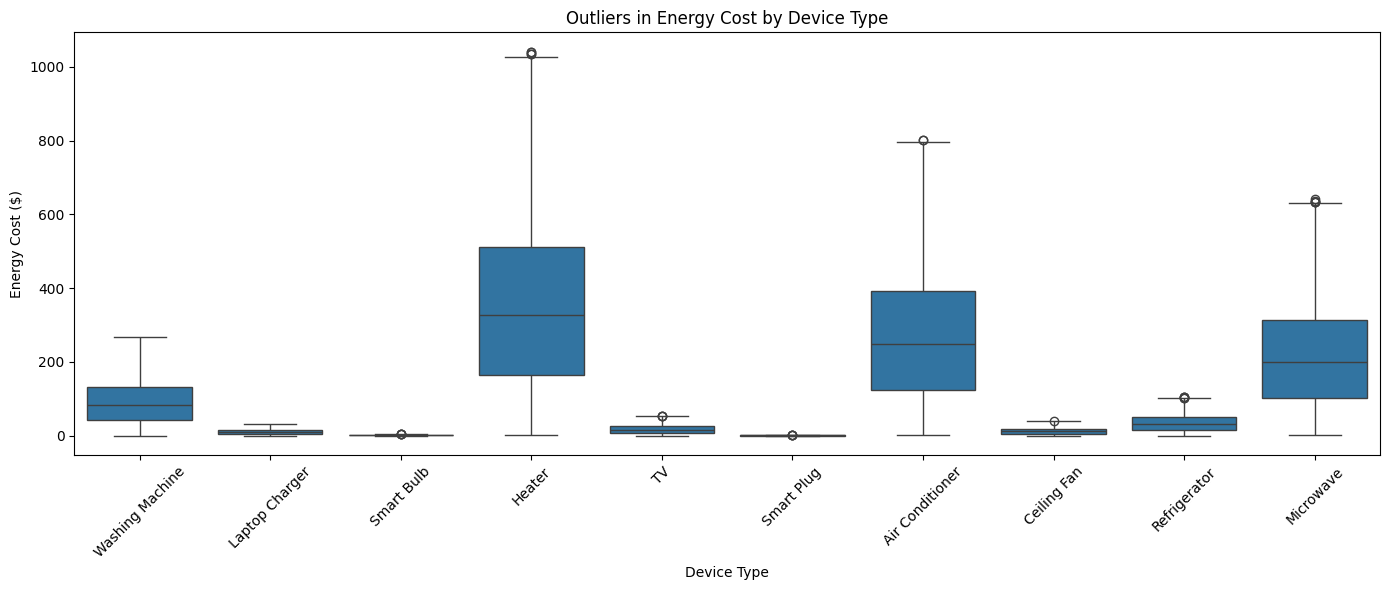

In [ ]:
# Create a boxplot to visualize the distribution and outliers of Energy Cost across device types
plt.figure(figsize=(14, 6))
sns.boxplot(data=smart_df, x='Device Type', y='Energy Cost ($)')
plt.xticks(rotation=45)
plt.title("Outliers in Energy Cost by Device Type")
plt.tight_layout()
plt.show()

In real-world smart home environments, it is reasonable to expect occasional spikes in energy consumption due to atypical but valid usage patterns. Since our goal is to analyze actual consumption behavior rather than filter for only typical usage, we believe that keeping these outliers provides a more accurate reflection of energy cost variability.

## 3.1 Energy Use by Device Type

We decided to examine average and median power consumption and energy cost by device type to better understand which devices are the primary drivers of household energy use. This helps identify whether overall energy patterns are being shaped by a few high-consumption devices or are more evenly distributed across all devices. Understanding this breakdown is critical for targeting energy optimization efforts: if energy costs are dominated by a small set of devices, interventions can be focused more strategically.

In [ ]:
# Mean and Median Power Consumption and Energy Cost by Device Type
device_energy_use = smart_ddf.groupby('Device Type')[['Power Consumption (W)', 'Energy Cost ($)', 'Cost Per Min']].agg([ 'mean', 'median']).compute()

# Display the results
print(device_energy_use)

                Power Consumption (W)           Energy Cost ($)          \
                                 mean    median            mean  median   
Device Type                                                               
Washing Machine            501.362613   502.100       91.334166   82.82   
Laptop Charger              60.155796    60.570       10.945805   10.06   
Smart Bulb                   9.986535     9.940        1.806946    1.61   
Heater                    2000.442311  2003.305      358.534313  326.12   
TV                         100.149217    99.810       18.183479   16.49   
Smart Plug                   5.003413     5.030        0.894899    0.81   
Air Conditioner           1502.079507  1507.230      273.262975  247.80   
Ceiling Fan                 74.807121    74.890       13.510962   12.37   
Refrigerator               197.889434   196.445       35.795042   32.70   
Microwave                 1199.574159  1204.170      218.612302  200.65   

                Cost Per


Takeaways:
*   Heaters and Air Conditioners dominate energy usage:
They have the highest mean and median power consumption (>1500 W) and the highest total energy cost, highlighting them as major drivers of household energy expenses.
*   Smart Plugs and Smart Bulbs are extremely low-cost:
Mean and median energy costs are close to zero, indicating that smart devices contribute very little to overall energy expenditure.
*   Smart Plugs and Smart Bulbs are extremely low-cost:
Mean and median energy costs are close to zero, indicating that smart devices contribute very little to overall energy expenditure.
*   Cost efficiency matters for certain devices:
For example, while TVs consume about 100 W on average, their Cost Per Min (~$0.20) is much lower than high-power devices, making them relatively more cost-efficient.






## 3.2 Energy Consumption and Cost by Time and Device Type

We visualized total power consumption and total energy cost by device across different timeframes (hourly, daily, and monthly) to better understand how usage and cost patterns evolve over time. By comparing these two trends side-by-side, we can assess whether energy costs are purely driven by consumption levels or whether additional pricing mechanisms, such as Time-of-Use (TOU) pricing, are influencing costs.

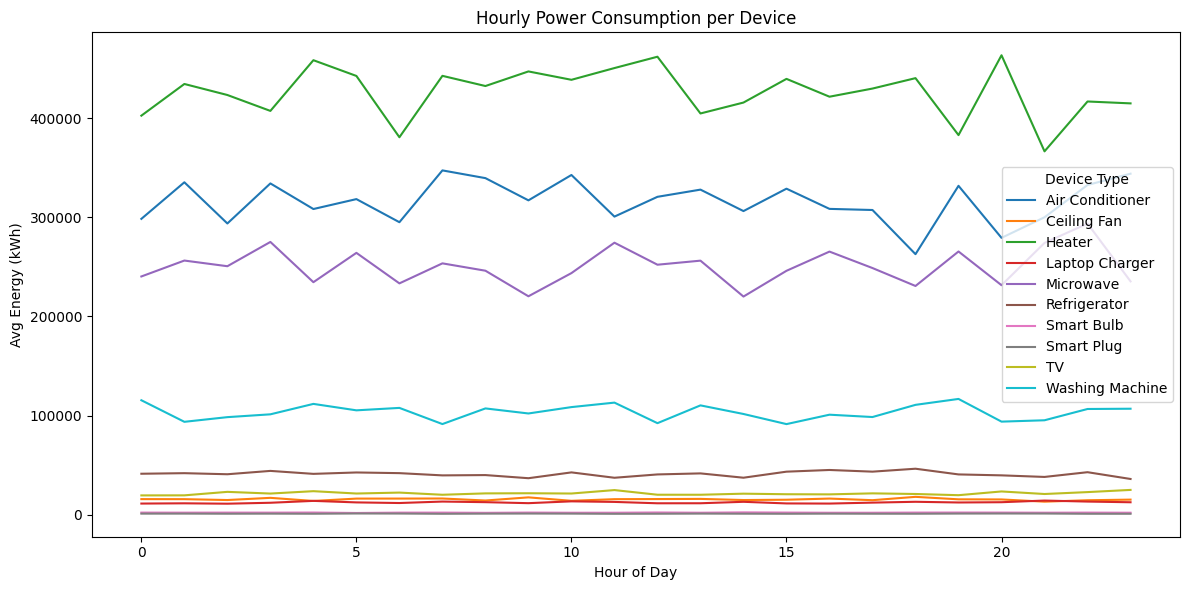

In [ ]:
# Create a line plot to visualize the total hourly power consumption pattern across device types
hourly = (
    smart_ddf.groupby(['Device Type', 'Hour'])['Power Consumption (W)']
    .sum()
    .compute()
    .unstack()
)

hourly.T.plot(figsize=(12, 6), title='Hourly Power Consumption per Device')
plt.ylabel('Avg Energy (kWh)')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.show()


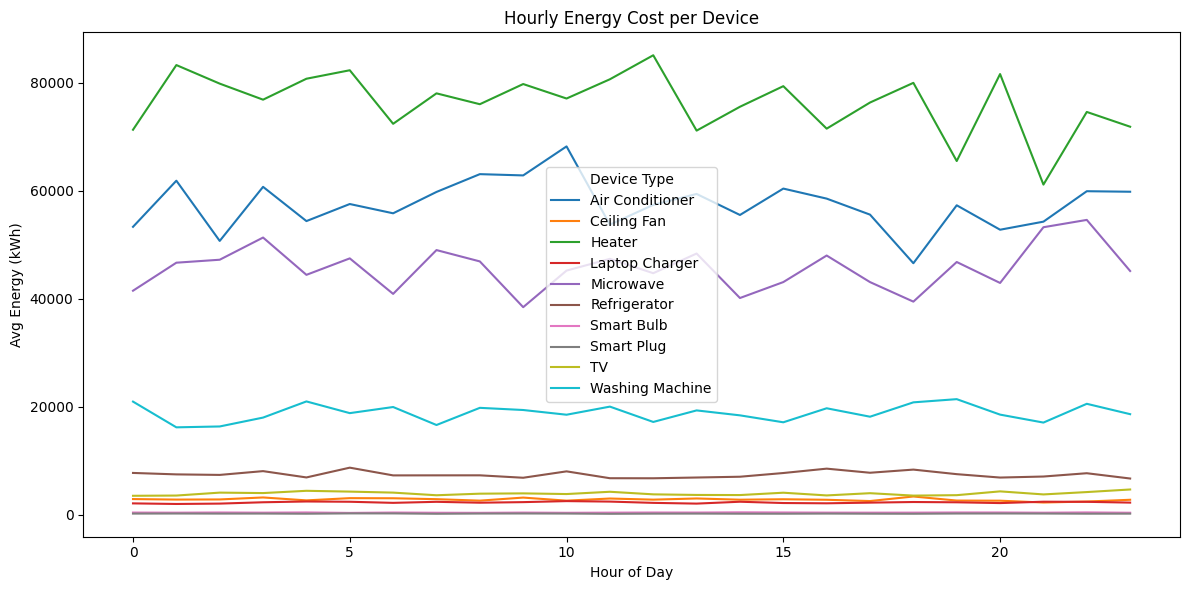

In [ ]:
# Create a line plot to visualize the total hourly energy cost pattern across device types
hourl_cost = (
    smart_ddf.groupby(['Device Type', 'Hour'])['Energy Cost ($)']
    .sum()
    .compute()
    .unstack()
)

hourl_cost.T.plot(figsize=(12, 6), title='Hourly Energy Cost per Device')
plt.ylabel('Avg Energy (kWh)')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.show()

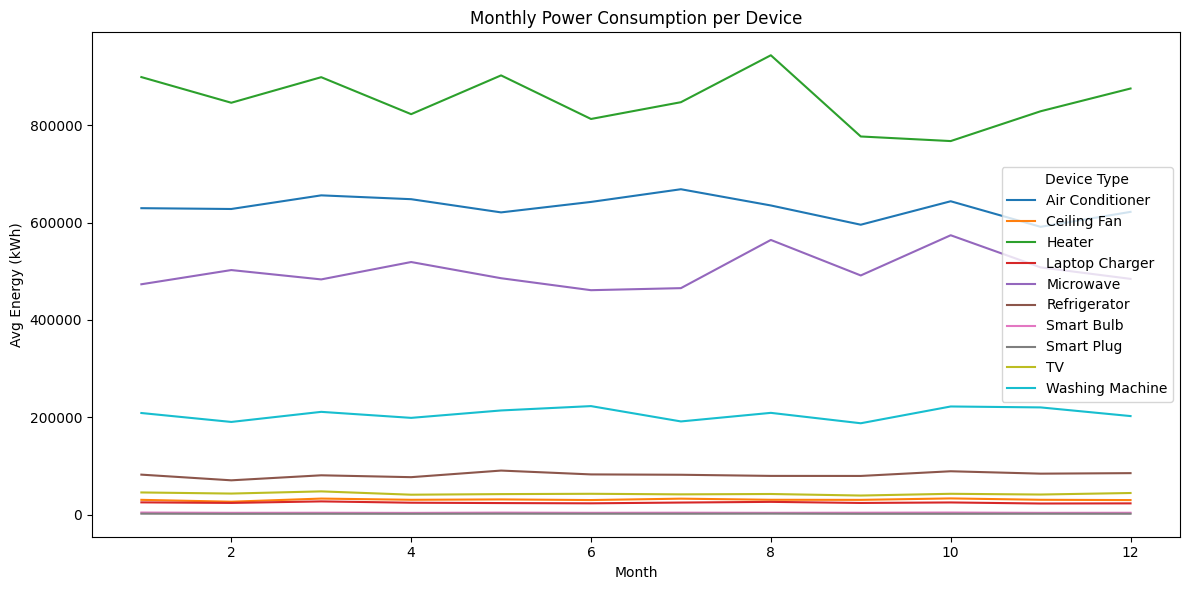

In [ ]:
# Create a line plot to visualize the total monthly power consumption pattern across device types
monthly = (
    smart_ddf.groupby(['Device Type', 'Month'])['Power Consumption (W)']
    .sum()
    .compute()
    .unstack()
)

monthly.T.plot(figsize=(12, 6), title='Monthly Power Consumption per Device')
plt.ylabel('Avg Energy (kWh)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


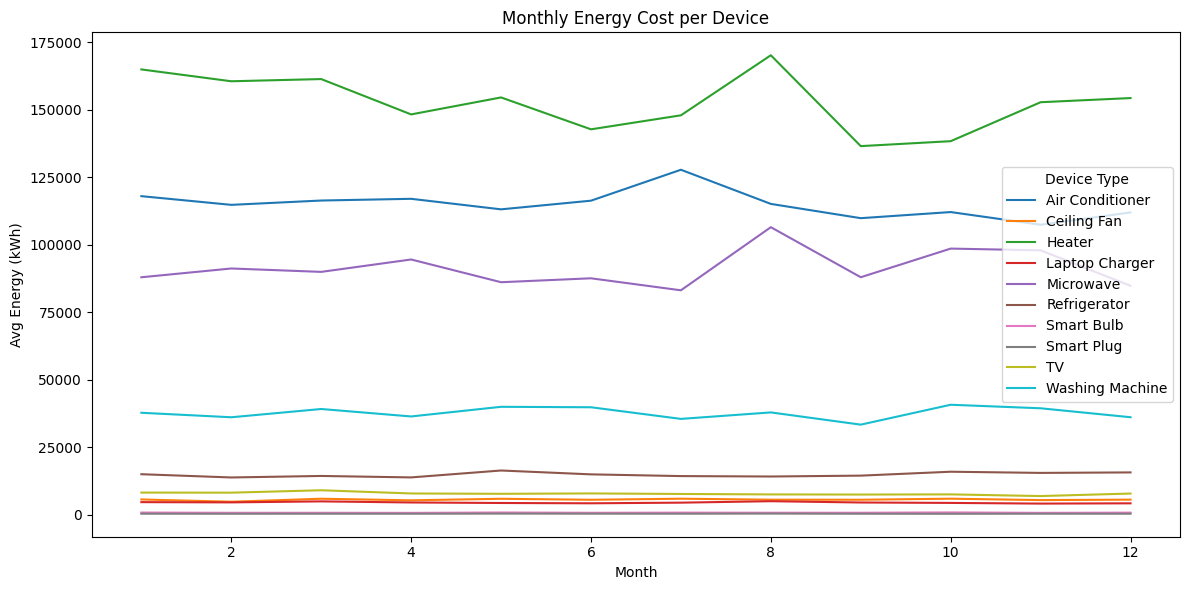

In [ ]:
# Create a line plot to visualize the total monthly energy cost pattern across device types
monthly_cost = (
    smart_ddf.groupby(['Device Type', 'Month'])['Energy Cost ($)']
    .sum()
    .compute()
    .unstack()
)

monthly_cost.T.plot(figsize=(12, 6), title='Monthly Energy Cost per Device')
plt.ylabel('Avg Energy (kWh)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


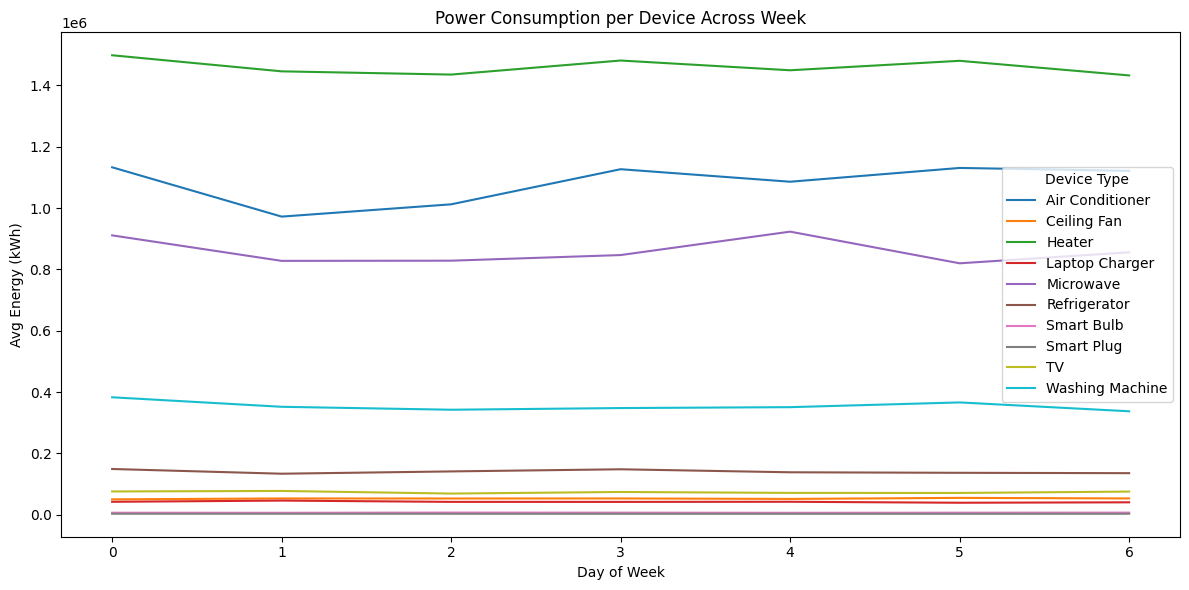

In [ ]:
# Create a line plot to visualize the total daily power consumption pattern across device types
dow = (
    smart_ddf.groupby(['Device Type', 'DayOfWeek'])['Power Consumption (W)']
    .sum()
    .compute()
    .unstack()
)

dow.T.plot(figsize=(12, 6), title='Power Consumption per Device Across Week')
plt.ylabel('Avg Energy (kWh)')
plt.xlabel('Day of Week')
plt.tight_layout()
plt.show()


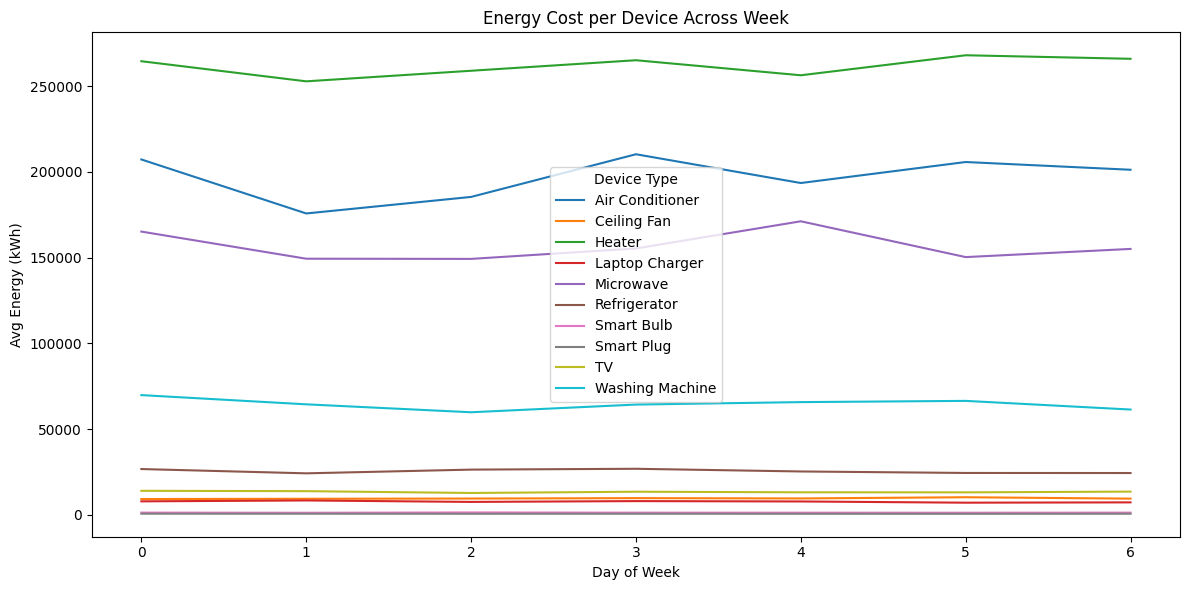

In [ ]:
# Create a line plot to visualize the total daily energy cost pattern across device types
dow_cost = (
    smart_ddf.groupby(['Device Type', 'DayOfWeek'])['Energy Cost ($)']
    .sum()
    .compute()
    .unstack()
)

dow_cost.T.plot(figsize=(12, 6), title='Energy Cost per Device Across Week')
plt.ylabel('Avg Energy (kWh)')
plt.xlabel('Day of Week')
plt.tight_layout()
plt.show()

**Takeaways**
1.	Heaters Dominate Both Usage and Cost:
*  	Heaters consistently show the highest power consumption (400,000–450,000 Wh per hour) and energy cost (~$80,000/hour).
*  	This reinforces that heaters are major energy drivers and should be prioritized for efficiency strategies.
2.	Energy Cost Patterns Don’t Always Match Consumption:
*  	While power consumption is relatively steady across hours, energy cost shows greater fluctuation.
*  	This suggests the presence of Time-of-Use (TOU) pricing—some hours cost more despite similar usage.
3.	Air Conditioners and Microwaves Show Hourly Volatility:
*  	Both devices show noticeable cost spikes around midday hours, even though usage doesn’t spike proportionally.
*  	These might align with peak demand periods when utility rates are higher.
4.	Plugs, Bulbs Have Minimal Impact:
*  	 Power consumption and energy cost for smart plugs and bulbs remain flat and negligible.
*  	This confirms that optimizing or replacing these devices may yield minimal savings.
5.	Fridge, TV, and Washing Machine: Low Variation:
*  	These devices show stable consumption and cost patterns, suggesting they operate independently of time-based behaviors (e.g., refrigerators run 24/7).


**Takeaways from different time-frames**

Hourly:
1. Midday Hours Are Most Expensive:
*  	Energy costs spike around 10 AM to 2 PM for high-power devices like heaters and air conditioners.
2. Off-Peak Hours Offer Cost Efficiency:
*  	During late-night and early-morning hours (12 AM – 6 AM), energy costs drop even though usage levels remain largely unchanged.
*  	Households could reduce bills by scheduling heavy-use appliances during these cheaper periods.
3. No Strong Behavior-Based Peaks:
*  	There is no sharp usage peak in the evening (e.g., 6–9 PM) as might be expected with typical home routines.
*  	This suggests device usage may be automated or staggered, and pricing (rather than behavior) is a stronger driver of hourly cost variance.

Monthly:
1.	Seasonal Consumption Peaks:
*  	Power usage for air conditioners, heaters, and microwaves shows seasonal variation.
*  	Notably, there’s a sharp increase in usage and cost around months 7–8 (likely July–August), which coincides with peak summer months and higher cooling needs.

## 3.3 Room-wise Energy Consumption

We created a series of stacked bar chart to examine how median energy consumption is distributed across different rooms and to identify which devices contribute most to the power usage in each space. We chose the top three consumed devices to assess whether room location influences energy demand.

In [ ]:
# calculate the average energy cost per minute for each device type in each room location
query = """
SELECT
  `Device Type`,
  `Room Location`,
  AVG(`Energy Cost ($)` / `Usage Duration (minutes)`) AS avg_cost_per_min
FROM smart_df
WHERE `Usage Duration (minutes)` > 0
GROUP BY `Device Type`, `Room Location`
"""

# Execute the query using pandasql
room_cost_df = ps.sqldf(query)

# Display the results
room_cost_df.head()

,Device Type,Room Location,avg_cost_per_min
0,Air Conditioner,Bathroom,3.008165
1,Air Conditioner,Bedroom,2.998696
2,Air Conditioner,Garage,3.013983
3,Air Conditioner,Kitchen,2.994903
4,Air Conditioner,Living Room,2.996618


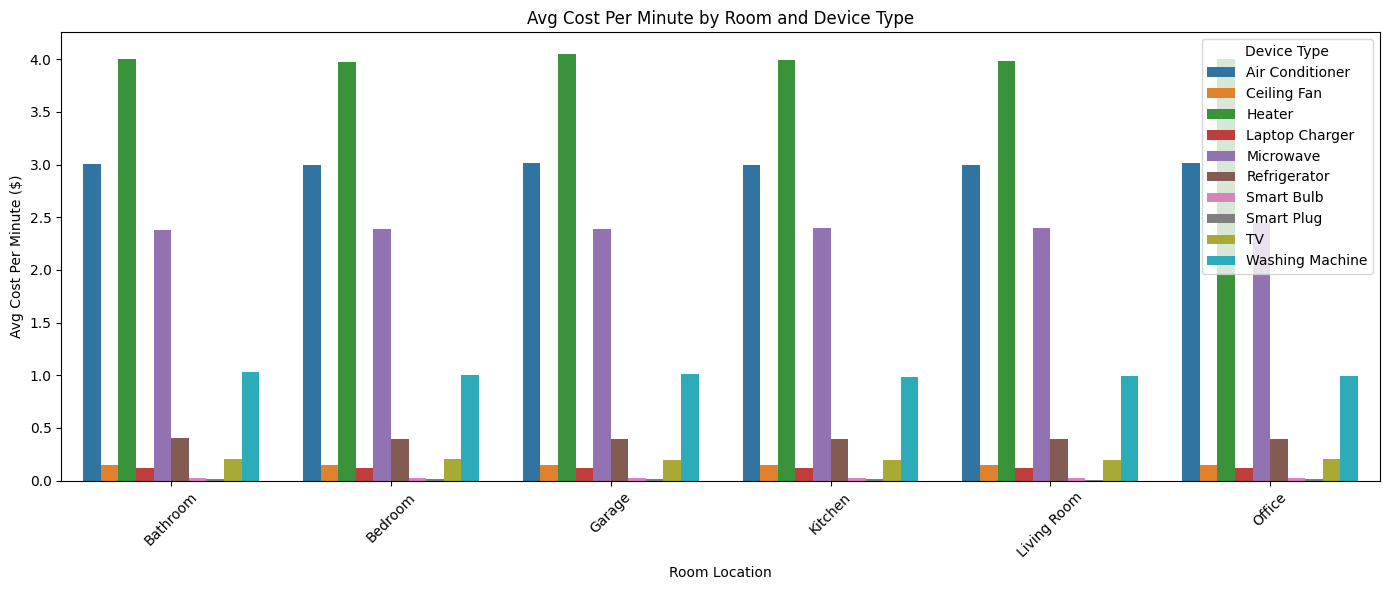

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(data=room_cost_df, x="Room Location", y="avg_cost_per_min", hue="Device Type")
plt.xticks(rotation=45)
plt.ylabel("Avg Cost Per Minute ($)")
plt.title("Avg Cost Per Minute by Room and Device Type")
plt.tight_layout()
plt.show()


Takeaway:

This chart confirms that average cost per minute remains consistent across different rooms for each device type. For instance, Heaters (\$4/min), Air Conditioners (\$3/min), and Microwaves (~\$2.4/min) show nearly identical cost behavior regardless of whether they’re in the bathroom, garage, or office. This suggests that room placement does not significantly influence per-minute energy cost, reinforcing that device type and usage time are the primary drivers of cost.

The anormaly of the dataset, such as the presence of microwave in the bathroom, is addressed in the conclusion.

## 3.4 On/Off Status and Energy

In [ ]:
# Calculate the average power consumption and energy cost for each device when On and Off separately
query = """
SELECT
    `Device ID`,
    AVG(CASE WHEN `On/Off Status` = 'On' THEN `Power Consumption (W)` ELSE 0 END) AS avg_power_on,
    AVG(CASE WHEN `On/Off Status` = 'Off' THEN `Power Consumption (W)` ELSE 0 END) AS avg_power_off,
    AVG(CASE WHEN `On/Off Status` = 'On' THEN `Energy Cost ($)` ELSE 0 END) AS avg_cost_on,
    AVG(CASE WHEN `On/Off Status` = 'Off' THEN `Energy Cost ($)` ELSE 0 END) AS avg_cost_off
FROM
    smart_df
GROUP BY
    `Device ID`;
"""

# Execute the query using pandasql
result_df = ps.sqldf(query, locals())

# Display the results
result_df.head()

,Device ID,avg_power_on,avg_power_off,avg_cost_on,avg_cost_off
0,D-1000,461.682222,179.880000,40.197778,21.585556
1,D-1001,138.000000,1.926667,2.590000,0.336667
2,D-1002,1053.085000,0.000000,125.640000,0.000000
3,D-1003,518.368571,14.957143,144.250000,2.897143
4,D-1004,13.332000,827.530000,4.586000,100.596000


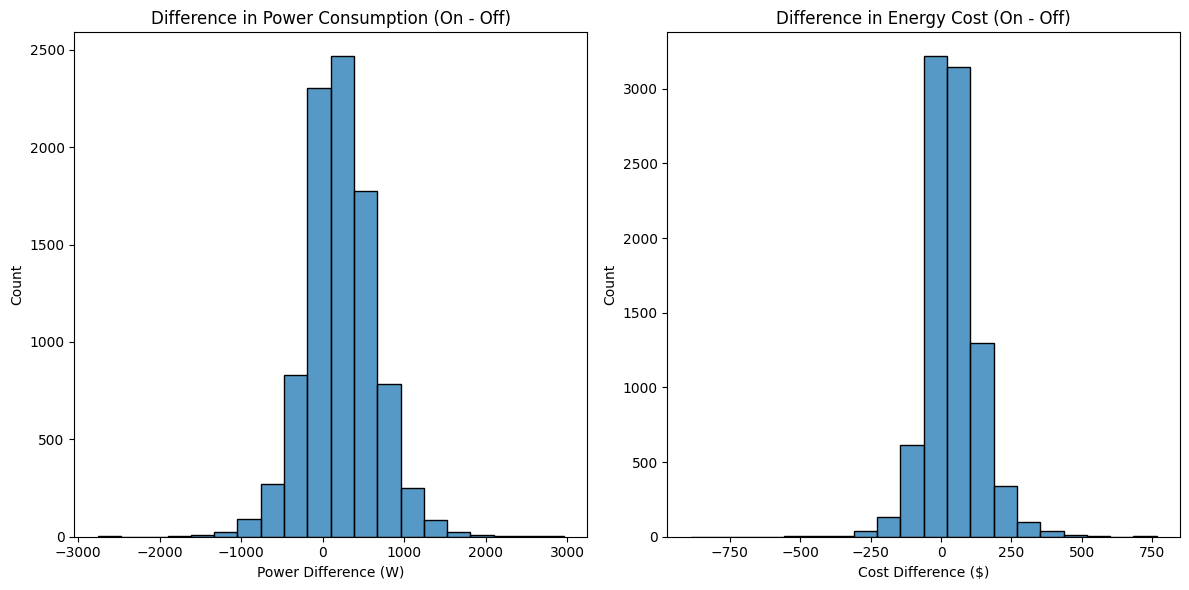

In [ ]:
# Calculate the difference between On and Off states
result_df['power_diff'] = result_df['avg_power_on'] - result_df['avg_power_off']
result_df['cost_diff'] = result_df['avg_cost_on'] - result_df['avg_cost_off']

# Visualize the differences using histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(result_df['power_diff'], ax=axes[0], bins=20)
axes[0].set_title('Difference in Power Consumption (On - Off)')
axes[0].set_xlabel('Power Difference (W)')

sns.histplot(result_df['cost_diff'], ax=axes[1], bins=20)
axes[1].set_title('Difference in Energy Cost (On - Off)')
axes[1].set_xlabel('Cost Difference ($)')

plt.tight_layout()
plt.show()

**Takeaways:**

1. Most Devices Consume More Power When On:
*  	The power difference histogram is centered above zero, confirming that devices generally consume more power when On — often by several hundred watts.

2. Cost Differences Are Smaller and Centered Near 0:
*  	While most devices still have higher energy costs in the On state (right side of the histogram), the distribution is much narrower and more symmetric.
*  	This suggests that the energy pricing structure (e.g., TOU pricing) may dampen or decouple the relationship between usage and cost, depending on when devices are run.

3. Evidence of Standby (Phantom) Loads:
*  	Notably, both histograms have meaningful left tails — indicating non-trivial cases where devices consume similar or even higher power when Off. This suggests that many smart devices draw baseline power in standby mode, contributing to unnecessary energy costs.


# Part 4: Linear Regression and Hypothesis Testing

In this section, we chose to use linear regression for hypothesis testing instead of a simple one-variable test because we wanted to assess the effect a specific feature on power consumption while controlling for other important factors. For instance,

Device type, device ID, and usage duration are all potential confounders that could influence power consumption.

Using linear regression allows us to isolate the unique contribution of On/Off status by holding these other variables constant. This approach provides a more accurate and reliable estimate of whether On/Off status has a statistically significant impact, beyond what can be explained by differences between devices or how long they are used. In contrast, a basic one-variable test would ignore these important sources of variation and could lead to misleading conclusions.

After running the linear regression, we conducted hypothesis testing. Based on the p-value, we interpret the results as follows:

*   If p-value < 0.05, we reject the null hypothesis, concluding that the target feature significantly contributes to predicting the outcome.
*   Otherwise, we fail to reject the null hypothesis, suggesting that the target feature does not have a significant effect.


## 4.1 Process and Encode Data

In [ ]:
# Make a copy of the dataset for preprocessing
encoded_smart_df = smart_df.copy()

We dropped the columns Timestamp, Timestamp_dt, Power Consumption (W), Cost Per Min, and Device ID because they are either identifiers, derived features, or direct proxies for the target variable. Timestamp and Timestamp_dt are raw time fields already captured by extracted features like hour, day, and month. Power Consumption (W) and Cost Per Min are closely tied to energy cost and could introduce data leakage if used as predictors. Device ID serves as a unique identifier and does not generalize across devices, making it unsuitable as a predictive feature.

In [ ]:
# drop columns that are either identifiers, derived features, or direct proxies for the target variable
encoded_smart_df = encoded_smart_df.drop(columns=['Timestamp', 'Timestamp_dt', 'Power Consumption (W)', 'Cost Per Min', 'Device ID'])

In [ ]:
# Process categorical features
# Identify categorical columns and convert to numerical
categorical_features = []
for col in encoded_smart_df.columns:
    if encoded_smart_df[col].dtype == 'string':
        categorical_features.append(col)

print(f"\nCategorical features: {categorical_features}")


Categorical features: ['Device Type', 'Room Location', 'On/Off Status']


In [ ]:
# Create lists of features
# Identify numerical features (excluding 'Energy_Cost' which will be our target)
numerical_features = [col for col in encoded_smart_df.columns
                     if col not in categorical_features + ['Energy Cost ($)', 'Power Consumption (W)', 'Cost Per Min', 'Device ID', 'Timestamp']]
print(f"\nNumerical features: {numerical_features}")


Numerical features: ['Temperature (°C)', 'Humidity (%)', 'Usage Duration (minutes)', 'Hour', 'DayOfWeek', 'Month']


In [ ]:
# Use one-hot encoding for categorical features
encoded_smart_df = pd.get_dummies(encoded_smart_df, columns=categorical_features, drop_first=True)

In [ ]:
# Prepare features and target
X = encoded_smart_df.drop(columns=['Energy Cost ($)'])
y = encoded_smart_df['Energy Cost ($)']

## 4.2 Descriptive Model and Linear Regression

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Create and evaluate a descriptive model
# Fit a linear regression model
lr_descriptive = LinearRegression()
lr_descriptive.fit(X, y)

LinearRegression()

In [ ]:
# Evaluate the model
lr_score_descriptive = lr_descriptive.score(X, y)
print(f"\nDescriptive Model R² Score: {lr_score_descriptive:.4f}")


Descriptive Model R² Score: 0.7033


The descriptive linear regression model achieved an R² score of 0.7033.

## 4.3 Interpreting Coefficients

In [ ]:
coefficients = pd.DataFrame({'feature': X.columns, 'coefficient': lr_descriptive.coef_})
print("\nModel Coefficients:")
print(coefficients.sort_values(by='coefficient', ascending=False))


Model Coefficients:
                        feature  coefficient
7            Device Type_Heater    86.242033
2      Usage Duration (minutes)    59.255329
16         Room Location_Garage     2.676350
19         Room Location_Office     2.639111
18    Room Location_Living Room     1.460880
20             On/Off Status_On     1.363631
0              Temperature (°C)     0.684221
17        Room Location_Kitchen     0.500467
4                     DayOfWeek     0.366106
3                          Hour    -0.121426
1                  Humidity (%)    -0.201493
15        Room Location_Bedroom    -0.273325
5                         Month    -0.612290
9         Device Type_Microwave   -54.906613
14  Device Type_Washing Machine  -182.324686
10     Device Type_Refrigerator  -237.215378
13               Device Type_TV  -255.259401
6       Device Type_Ceiling Fan  -259.445675
8    Device Type_Laptop Charger  -262.456072
12       Device Type_Smart Plug  -270.933171
11       Device Type_Smart Bulb  -

The model coefficients show how each feature affects energy cost after controlling for other variables. Among all predictors, Usage Duration (minutes) has the largest positive impact: a one-unit increase in usage time is associated with the largest rise in energy cost. Device type also matters: heaters (Device Type_Heater) are linked with much higher energy costs, while devices like smart bulbs, smart plugs, and laptop chargers show strong negative coefficients, reflecting their relatively low energy consumption. Environmental factors like Temperature (°C) and Humidity (%) have smaller effects, suggesting that internal device characteristics and usage patterns are the primary drivers of energy cost.

## 4.4 Hypothesis Testing

In the next step, we use this framework to conduct hypothesis testing on individual coefficients. Although our descriptive linear regression model achieved a moderate R² score of 0.7033, linear regression hypothesis testing is valuable for our analysis. Linear regression allows us to estimate and test the individual impact of specific variables (e.g., On/Off Status, Room Location, Temperature) on energy cost while controlling for confounders such as usage duration and device type. Even if the model doesn’t perfectly predict energy cost, we believe the coefficient significance tests still provide insights about which factors are meaningfully associated with cost and which are not.

### 4.4.1 Testing for all coefficients = 0

Null Hypothesis: All coefficients of the unregularized model are 0, i.e., $\beta_0 = \beta_1 = ... = \beta_n = 0$.

In [ ]:

print("\n--- Hypothesis Test 1: All Coefficients = 0 ---")
original_r2 = lr_score_descriptive
simulated_r2 = []

for _ in range(1000):
    # Shuffle the features
    X_shuffled = X.copy()
    X_shuffled = resample(X_shuffled, replace=False)

    # Fit model with shuffled data
    lr_perm = LinearRegression()
    lr_perm.fit(X_shuffled, y)

    # Record R² score
    simulated_r2.append(lr_perm.score(X_shuffled, y))

simulated_r2 = np.array(simulated_r2)
all_zero_p_value = np.mean(simulated_r2 >= original_r2)

print(f"Original R² value: {original_r2:.4f}")
print(f"Mean of simulated R² values: {np.mean(simulated_r2):.4f}")
print(f"P-value for all coefficients = 0: {all_zero_p_value:.4f}")
print(f"Reject null hypothesis: {all_zero_p_value < 0.05}")


--- Hypothesis Test 1: All Coefficients = 0 ---
Original R² value: 0.7033
Mean of simulated R² values: 0.0004
P-value for all coefficients = 0: 0.0000
Reject null hypothesis: True


### 4.4.2 Testing for one particular coefficient is zero

Null hypothesis: The coefficient of `Temperature (°C)` in the full unregularized linear regression is 0.

In [ ]:
# linear regression without the temperature feature
feature_to_test = 'Temperature (°C)'
X_reduced = X.drop(columns=[feature_to_test])
lr_reduced = LinearRegression()
lr_reduced.fit(X_reduced, y)
predicted = lr_reduced.predict(X_reduced)
residuals = y - predicted

# find observed r2 score and initialize array to store simulated r2 scores
observed_r2 = lr_reduced.score(X_reduced, y)
simulated_r2_one = []

for _ in range(1000):
    # shuffle the residual, predict using linear regression without temperature, find r2 score of new lr model
    shuffled_residuals = np.random.permutation(residuals)
    simulated_y = predicted + shuffled_residuals
    simulated_lr = LinearRegression()
    simulated_lr.fit(X_reduced, simulated_y)
    simulated_r2_one.append(simulated_lr.score(X_reduced, simulated_y))

simulated_r2_one = np.array(simulated_r2_one)
# calculate p-value based on observed_r2 and simulated_r2
one_zero_p_value = np.mean(simulated_r2_one >= observed_r2)

print(f"Observed R² without {feature_to_test}: {observed_r2:.4f}")
print(f"Mean of simulated R² values: {np.mean(simulated_r2_one):.4f}")
print(f"P-value for {feature_to_test} coefficient = 0: {one_zero_p_value:.4f}")
print(f"Reject null hypothesis: {one_zero_p_value < 0.05}")

Observed R² without Temperature (°C): 0.7033
Mean of simulated R² values: 0.7033
P-value for Temperature (°C) coefficient = 0: 0.5340
Reject null hypothesis: False


Null hypothesis: The coefficient of `On/Off Status_On` in the full unregularized linear regression is 0.

In [ ]:
# linear regression without the on/off status feature
feature_to_test = 'On/Off Status_On'
X_reduced = X.drop(columns=[feature_to_test])
lr_reduced = LinearRegression()
lr_reduced.fit(X_reduced, y)
predicted = lr_reduced.predict(X_reduced)
residuals = y - predicted

# find observed r2 score and initialize array to store simulated r2 scores
observed_r2 = lr_reduced.score(X_reduced, y)
simulated_r2_one = []

for _ in range(1000):
    # shuffle the residual, predict using linear regression without temperature, find r2 score of new lr model
    shuffled_residuals = np.random.permutation(residuals)
    simulated_y = predicted + shuffled_residuals
    simulated_lr = LinearRegression()
    simulated_lr.fit(X_reduced, simulated_y)
    simulated_r2_one.append(simulated_lr.score(X_reduced, simulated_y))

simulated_r2_one = np.array(simulated_r2_one)
# calculate p-value based on observed_r2 and simulated_r2
one_zero_p_value = np.mean(simulated_r2_one >= observed_r2)

print(f"Observed R² without {feature_to_test}: {observed_r2:.4f}")
print(f"Mean of simulated R² values: {np.mean(simulated_r2_one):.4f}")
print(f"P-value for {feature_to_test} coefficient = 0: {one_zero_p_value:.4f}")
print(f"Reject null hypothesis: {one_zero_p_value < 0.05}")

Observed R² without On/Off Status_On: 0.7033
Mean of simulated R² values: 0.7034
P-value for On/Off Status_On coefficient = 0: 0.5490
Reject null hypothesis: False


Null hypothesis: The coefficient of `DayOfWeek` in the full unregularized linear regression is 0.

In [ ]:
# linear regression without the DayOfWeek feature
feature_to_test = 'DayOfWeek'
X_reduced = X.drop(columns=[feature_to_test])
lr_reduced = LinearRegression()
lr_reduced.fit(X_reduced, y)
predicted = lr_reduced.predict(X_reduced)
residuals = y - predicted

# find observed r2 score and initialize array to store simulated r2 scores
observed_r2 = lr_reduced.score(X_reduced, y)
simulated_r2_one = []

for _ in range(1000):
    # shuffle the residual, predict using linear regression without temperature, find r2 score of new lr model
    shuffled_residuals = np.random.permutation(residuals)
    simulated_y = predicted + shuffled_residuals
    simulated_lr = LinearRegression()
    simulated_lr.fit(X_reduced, simulated_y)
    simulated_r2_one.append(simulated_lr.score(X_reduced, simulated_y))

simulated_r2_one = np.array(simulated_r2_one)
# calculate p-value based on observed_r2 and simulated_r2
one_zero_p_value = np.mean(simulated_r2_one >= observed_r2)

print(f"Observed R² without {feature_to_test}: {observed_r2:.4f}")
print(f"Mean of simulated R² values: {np.mean(simulated_r2_one):.4f}")
print(f"P-value for {feature_to_test} coefficient = 0: {one_zero_p_value:.4f}")
print(f"Reject null hypothesis: {one_zero_p_value < 0.05}")

Observed R² without DayOfWeek: 0.7033
Mean of simulated R² values: 0.7034
P-value for DayOfWeek coefficient = 0: 0.5510
Reject null hypothesis: False


Null hypothesis: The coefficient of `Room Location_Garage` in the full unregularized linear regression is 0.

In [ ]:
# linear regression without the room location feature
feature_to_test = 'Room Location_Garage'
X_reduced = X.drop(columns=[feature_to_test])
lr_reduced = LinearRegression()
lr_reduced.fit(X_reduced, y)
predicted = lr_reduced.predict(X_reduced)
residuals = y - predicted

# find observed r2 score and initialize array to store simulated r2 scores
observed_r2 = lr_reduced.score(X_reduced, y)
simulated_r2_one = []

for _ in range(1000):
    # shuffle the residual, predict using linear regression without temperature, find r2 score of new lr model
    shuffled_residuals = np.random.permutation(residuals)
    simulated_y = predicted + shuffled_residuals
    simulated_lr = LinearRegression()
    simulated_lr.fit(X_reduced, simulated_y)
    simulated_r2_one.append(simulated_lr.score(X_reduced, simulated_y))

simulated_r2_one = np.array(simulated_r2_one)
# calculate p-value based on observed_r2 and simulated_r2
one_zero_p_value = np.mean(simulated_r2_one >= observed_r2)

print(f"Observed R² without {feature_to_test}: {observed_r2:.4f}")
print(f"Mean of simulated R² values: {np.mean(simulated_r2_one):.4f}")
print(f"P-value for {feature_to_test} coefficient = 0: {one_zero_p_value:.4f}")
print(f"Reject null hypothesis: {one_zero_p_value < 0.05}")

Observed R² without Room Location_Garage: 0.7033
Mean of simulated R² values: 0.7034
P-value for Room Location_Garage coefficient = 0: 0.5750
Reject null hypothesis: False


The hypothesis tests for individual features (Temperature (°C), On/Off Status_On, DayOfWeek, and Room Location_Garage) all resulted in p-values well above 0.05, meaning we fail to reject the null hypothesis in every case. This suggests that none of these features have a statistically significant impact on energy cost after controlling for other variables in the model.

Interestingly, despite Temperature and On/Off Status seeming intuitively important — since we expect devices to behave differently when turned on, energy usage to vary with temperature, and cost patterns to shift based on day-of-week (especially under a Time-of-Use (TOU) pricing system) —  the results show none of these factors are statistically significant predictors after controlling for other variables.

This suggests that energy cost in this dataset is primarily driven by device type and usage duration, rather than environmental conditions, time-based effects, or device status alone. Even though TOU pricing often causes cost fluctuations across days and hours, its impact appears minimal here.

Overall, the model relies more heavily on how long and what type of device is used rather than contextual factors like room location, temperature, or whether the device is turned "on" or "off" at a given time.

### Additional Feature Engineering

We decided to create additional time-based features — Hour, Day, Month, WeekDay, and TimeOfDay — to better capture potential patterns in energy consumption related to time.

In [ ]:
# 3. FEATURE ENGINEERING - Create time-related features for analysis
df = smart_df.copy()

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

if 'Timestamp' in smart_df.columns:
    # Extract time components
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['WeekDay'] =df['Timestamp'].dt.weekday < 5  # True for weekdays, False for weekends
    df['TimeOfDay'] = pd.cut(df['Hour'],
                                  bins=[0, 6, 12, 18, 24],
                                  labels=['Night', 'Morning', 'Afternoon', 'Evening'])

    print("Created time-based features: Hour, Day, Month, WeekDay, TimeOfDay")


FEATURE ENGINEERING
Created time-based features: Hour, Day, Month, WeekDay, TimeOfDay


# Part 5: Unsupervised Learning Models: PCA & KMeans

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 5.1 Encoding Categorical Variables

Before proceeding with modeling, we begin by preparing our dataset for analysis. One of the categorical columns in our dataset, On/Off Status, indicates whether a device was operating. Since machine learning models require numerical input, we map this binary status to integers — assigning 1 for "On" and 0 for "Off". This transformation will allow us to later include this feature in our predictive models.

In [ ]:
# Convert 'On'/'Off' device status to binary format (1 = On, 0 = Off)
df['On/Off Status'] = df['On/Off Status'].map({'On': 1, 'Off': 0})

Several of the most important predictive variables in our dataset — including Device Type, Room Location, TimeOfDay, and DayOfWeek — are categorical. To convert these into a format suitable for machine learning algorithms, we apply One-Hot Encoding. This creates binary columns for each category, allowing the models to interpret these discrete labels as independent features. We drop the first category in each case. This is because if we include all the one-hot encoded columns for a categorical feature our model, we introduce perfect multicollinearity, meaning one column can be exactly predicted from the others,  which can break linear models and inflate feature importance.

In [ ]:
# One-hot encode key categorical features and drop the first to avoid multicollinearity
categorical_cols = ['Device Type', 'Room Location', 'TimeOfDay', 'DayOfWeek']
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

## 5.2 PCA

After we finish encoding the categorical variables and preparing the numerical features, the next step is to apply Principal Component Analysis (PCA). The goal here is twofold: first, to reduce the dimensionality of the dataset by condensing the many one-hot encoded columns into a smaller set of meaningful components; and second, to deal with potential multicollinearity. Since PCA transforms correlated variables into a set of independent (orthogonal) principal components, it helps improve both the stability and interpretability of later models.

Before running PCA, we standardize all the features using a StandardScaler. This is critical because PCA is sensitive to the scale of the input variables. Without standardization, features with larger values would overpower the results and distort the principal components, leading to misleading conclusions.

Once the features are standardized, we fit PCA and plot the cumulative explained variance to figure out how many components we need to capture at least 80% of the dataset’s original variance. Based on the plot, we select the smallest number of components that clear this 80% threshold. Using this reduced set of components, we transform the dataset—keeping most of the important information while cutting down on complexity and making downstream modeling more efficient.

Even though some machine learning models we'll use later—like Random Forests and XGBoost—can naturally handle multicollinearity, running PCA still offers real advantages. It streamlines the data, speeds up training times, reduces noise, and gives us a compact version of the dataset that’s also useful for clustering and exploration.

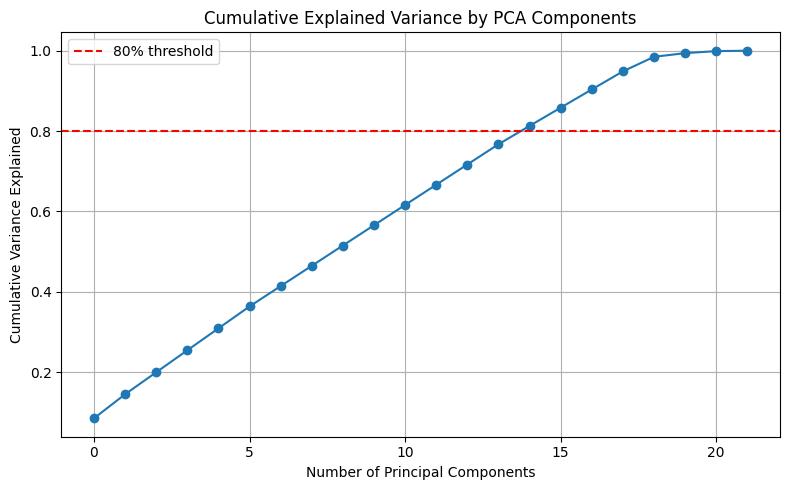

Number of principal components used: 15


In [ ]:
# Combine selected numeric features with encoded categorical features
# These serve as input for PCA to reduce dimensionality
pca_features = ['Usage Duration (minutes)', 'Temperature (°C)', 'Humidity (%)', 'Hour']
X_raw = pd.concat([df[pca_features], df_encoded], axis=1)

# Standardize all features to ensure PCA treats all inputs equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Visualize the cumulative variance explained by each principal component
pca_full = PCA().fit(X_scaled)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Apply PCA to reduce dimensionality while retaining 80% of variance
pca = PCA(n_components=0.80)
X_pca = pca.fit_transform(X_scaled)
print(f"Number of principal components used: {X_pca.shape[1]}")

The plot above shows how cumulative variance increases with each added principal component. We observe a steady climb, with the curve crossing the 80% threshold at around the 15th component. This indicates that the first 15 principal components capture the majority of the variance in the dataset, while the remaining components contribute incrementally less. As a result, we move forward using only the number of components required to exceed the 80% threshold. This strikes a balance between dimensionality reduction and information retention.

To further validate this choice, we examine the explained_variance_ratio_ attribute from PCA, which quantifies how much variance each component explains individually. By reviewing both the individual and cumulative variance values, we ensure that the retained components contribute meaningfully to the data’s structure—not just mathematically, but in terms of information density. If only a few components had dominated the variance, it might have led us to reconsider how many to include. Fortunately, in our case, the variance is distributed across multiple components, supporting our decision to keep the top 15.

In [ ]:
# Retrieve the proportion of variance each component explains
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Print both individual and cumulative variance explained for each principal component
# This helps justify the number of components we retained (e.g., to reach 80%)
for i, (ev, cv) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"PC{i}: {ev:.4f} explained, cumulative: {cv:.4f}")

PC1: 0.0848 explained, cumulative: 0.0848
PC2: 0.0599 explained, cumulative: 0.1447
PC3: 0.0548 explained, cumulative: 0.1994
PC4: 0.0547 explained, cumulative: 0.2541
PC5: 0.0546 explained, cumulative: 0.3087
PC6: 0.0546 explained, cumulative: 0.3633
PC7: 0.0506 explained, cumulative: 0.4140
PC8: 0.0506 explained, cumulative: 0.4645
PC9: 0.0505 explained, cumulative: 0.5150
PC10: 0.0505 explained, cumulative: 0.5655
PC11: 0.0504 explained, cumulative: 0.6160
PC12: 0.0504 explained, cumulative: 0.6663
PC13: 0.0504 explained, cumulative: 0.7167
PC14: 0.0503 explained, cumulative: 0.7670
PC15: 0.0457 explained, cumulative: 0.8127


Our results indicate that the variance is distributed relatively evenly across the components, with each new principal component contributing a modest but consistent share of information. It takes approximately 15 components to surpass the 80% cumulative variance threshold. The absence of a sharp elbow or dominant early component in the curve suggests that no single feature drives the dataset’s structure. Instead, meaningful patterns are dispersed across many features.

This observation supports our decision to retain components until the 80% mark. It allows us to preserve most of the underlying signal in the data while reducing dimensionality, minimizing noise, and helping prevent overfitting in downstream models.

## 5.3 KMeans

To uncover hidden patterns in the data, we applied KMeans clustering on the PCA-reduced features. This unsupervised learning step helped us find natural groupings based on how devices were used and their overall characteristics. Instead of trying to predict a specific outcome, our goal here was to reveal structure in the data that could improve future modeling.

Each data point was assigned to one of five clusters, grouping observations by similar usage behavior. We added these cluster labels back into the dataset as a new feature called Cluster_PCA80. This gives our supervised models a head start by highlighting different usage patterns, instead of forcing them to learn everything from raw features alone.

To get a better sense of how well the clustering worked, we plotted the data on the first two principal components and colored each point by its cluster. Even though this is just a 2D view of a higher-dimensional space, it still gives a clear sense of how distinct the clusters are.

We chose k = 5 clusters based on some initial testing and what made sense given the context of the data. That said, a more formal approach like the elbow method could help refine this choice in future work. Overall, this step turned unsupervised patterns into a structured, meaningful feature that improved the performance of our predictive models.

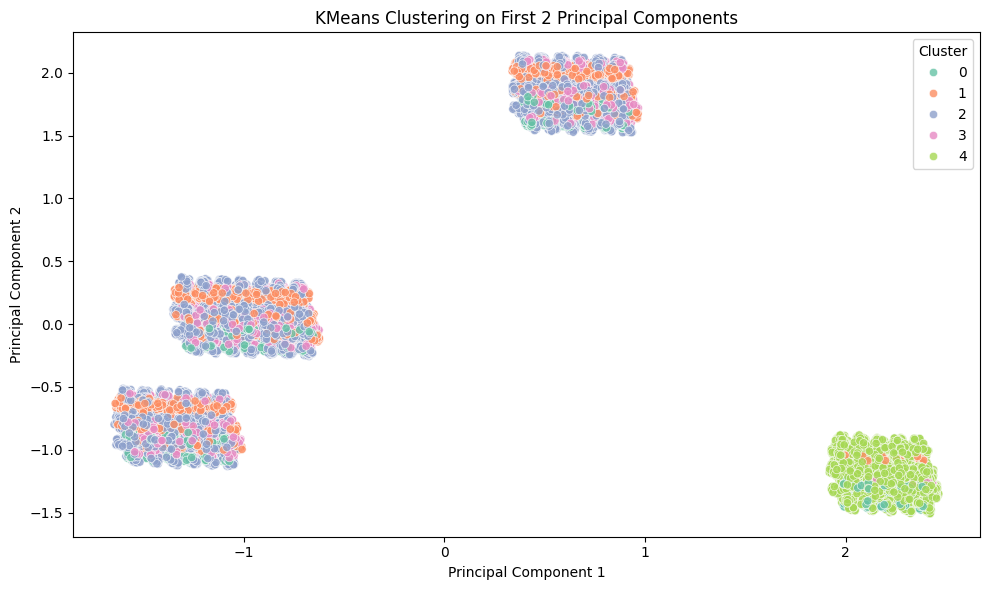

In [ ]:
# Fit KMeans on PCA data (with 80% explained variance) to group similar usage patterns
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_PCA80'] = kmeans.fit_predict(X_pca)

# For visualization: reduce data to 2 principal components
# This 2D version is only used for plotting, not clustering
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)

# Create DataFrame for plotting cluster results
plot_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
plot_df['Cluster'] = df['Cluster_PCA80']

# Visualize the clusters in 2D PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', alpha=0.8)
plt.title("KMeans Clustering on First 2 Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

The scatter plot above shows the results of applying KMeans clustering to our PCA-reduced dataset, projected onto the first two principal components. Each point represents a single device usage instance, and the color shows which of the five clusters it belongs to.

From the plot, we can see that the clusters are fairly well-separated in this 2D space. Cluster 4 (green) stands out the most in the bottom-right corner, which suggests it may represent a very different kind of usage — possibly involving high-energy devices or longer usage durations. Clusters 3 and 0 also look pretty distinct, which means the algorithm was able to pick up on unique patterns in behavior even after reducing the data’s dimensions.

On the other hand, Clusters 1 and 2 have more overlap, which might mean their differences are harder to see in two dimensions or that they represent more subtle variations in device usage. Even though PCA compresses a complex feature space into just two components, this plot still gives a useful snapshot of how the data is structured.

Overall, the visualization shows that our cluster labels are capturing real behavioral patterns. By including the cluster feature (Cluster_PCA80) in our supervised models, we’re giving them a helpful shortcut to understand different usage contexts without having to learn everything from scratch.


# Part 6: Supervised Learning Models

After wrapping up our unsupervised learning steps with PCA and KMeans clustering, we shifted our focus to supervised learning to start building predictive models. Our main goal here is to predict energy cost using a mix of device-level, environmental, and time-based features.

While PCA and clustering helped us find structure in the data and group similar usage behaviors, supervised learning lets us take it further by actually predicting energy cost. This is a key step for smart home applications, where knowing future costs can help with things like scheduling, automation, and saving energy more efficiently.


## 6.1 Setup

In this step, we put together the final set of features for our supervised learning models. We included Usage Duration, Temperature, Humidity, Hour, Month, and On/Off Status as our main predictors of energy cost. We left out Power Consumption on purpose, since energy cost is calculated directly from it — including it would make it too easy for the model to "cheat" and just reverse the formula, which wouldn’t tell us anything useful about the model’s real predictive ability.

We also added Cluster_PCA80, which is the cluster label we got from running KMeans on the PCA-reduced data. This helps the model pick up on general patterns in usage behavior that aren’t obvious from individual features. On top of that, we included one-hot encoded versions of categorical variables like Device Type, Room Location, Time of Day, and Day of Week, so the model can interpret them properly.

Once the feature set was ready, we split the data into training and testing sets using an 80/20 split and a fixed random seed to make sure our results are reproducible. This set us up to start building and testing our predictive models in the next steps.

In [ ]:
# Define numeric and contextual features (excluding power consumption to avoid data leakage)
features = [
    'Usage Duration (minutes)', 'Temperature (°C)', 'Humidity (%)',
    'Hour', 'Month', 'On/Off Status', 'Cluster_PCA80'  # Cluster from PCA+KMeans
]

# Combine numerical features with one-hot encoded categorical variables
X_supervised = pd.concat([df[features], df_encoded], axis=1)

# Define target variable: energy cost
y = df['Energy Cost ($)']

# Train-test split for model evaluation (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_supervised, y, test_size=0.2, random_state=42)

## 6.2 Linear Regression

We started our supervised modeling by fitting a Linear Regression model to serve as a baseline. While linear models can’t capture complex or nonlinear patterns, they’re easy to interpret and give us a solid reference point to compare against. By seeing how well this simple model predicts energy cost, we can figure out whether we actually need more advanced techniques.

We trained the model on 80% of the data and tested it on the remaining 20%. To measure how well it performed, we looked at the R² score (which tells us how much of the variation in energy cost the model can explain — higher is better) and the Mean Squared Error (MSE), which shows how far off the predictions are on average — lower is better. These metrics give us a good starting point to judge how much better models like Random Forest and XGBoost perform.

In [ ]:
# Linear Regression is used as a simple baseline model for comparison.
# It helps us establish a reference point to evaluate more complex models later.

print("\nTraining baseline Linear Regression model...")

# Instantiate and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict on both train and test sets
y_pred_lin_test = lin_reg.predict(X_test)
y_pred_lin_train = lin_reg.predict(X_train)

# Evaluate using R² (explained variance) and Mean Squared Error
print(f"Test Set R²: {r2_score(y_test, y_pred_lin_test):.4f}")
print(f"Train Set R²: {r2_score(y_train, y_pred_lin_train):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lin_test):.4f}")


Training baseline Linear Regression model...
Test Set R²: 0.6937
Train Set R²: 0.7056
Mean Squared Error: 8198.8481


The baseline Linear Regression model achieves a Test Set R² of 0.6937 and a Train Set R² of 0.7056, meaning it can explain about 69–70% of the variance in energy cost. However, the Mean Squared Error (MSE) on the test set is relatively high at 8198.85, which shows that while the model captures general trends, it struggles to make precise predictions for individual cases. The small gap between the training and testing R² scores suggests that the model isn’t significantly overfitting. Instead, it’s more likely underfitting because of its limited ability to capture more complex, nonlinear patterns in the data. This performance highlights the need to move toward more flexible models, like Random Forests and XGBoost, in the next sections.

## 6.3 XGBoost Regression

After setting a baseline with Linear Regression, we move on to XGBoost Regression to better capture non-linear relationships in the data. XGBoost is an ensemble method that builds decision trees one after another, with each new tree working to correct the mistakes made by the ones before it. This approach allows XGBoost to model complex, non-linear patterns, which are likely present given the variety of device types, usage patterns, and environmental factors in our dataset.

We chose XGBoost because it tends to outperform simple linear models when the relationship between the features and the target isn’t purely linear. Plus, XGBoost has built-in regularization techniques, like shrinkage and subsampling, which help prevent overfitting even as the model becomes more flexible. This makes it a strong next step as we aim for better predictive performance while still making sure the model generalizes well to new data.

For the initial setup, we chose hyperparameters based on standard practice and domain knowledge. The learning rate (eta) was set to 0.1 to keep model updates gradual, and the maximum tree depth (max_depth) was set to 5 to balance flexibility with generalization.

In [ ]:
# XGBoost is a powerful gradient boosting method that often outperforms simpler models
# like Linear Regression, especially when capturing nonlinear patterns and interactions.
# Here, we initialize XGBoost with eta=0.1 (learning rate) and max_depth=5 for balanced complexity.

print("\nTraining initial XGBoost model...")

# Instantiate and fit the model
xgb_reg = XGBRegressor(eta=0.1, max_depth=5, random_state=42)
xgb_reg.fit(X_train, y_train)

# Make predictions on training and testing sets
y_pred_xgb_test = xgb_reg.predict(X_test)
y_pred_xgb_train = xgb_reg.predict(X_train)

# Evaluate using R² and MSE
print(f"Test Set R²: {r2_score(y_test, y_pred_xgb_test):.4f}")
print(f"Train Set R²: {r2_score(y_train, y_pred_xgb_train):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_xgb_test):.4f}")


Training initial XGBoost model...
Test Set R²: 0.8507
Train Set R²: 0.8559
Mean Squared Error: 3997.1053


After fitting our initial XGBoost model, we get a test set R² of 0.8507 and a training set R² of 0.8559, showing that the model captures the underlying structure of the data well without significant overfitting. The Mean Squared Error (MSE) on the test set is around 3997.11. Compared to the baseline Linear Regression model — which had a test R² of 0.6937 and a much higher MSE of about 8198.85 — the XGBoost model shows a big improvement in predictive accuracy. This suggests that the relationships between features and energy cost in our dataset are nonlinear and complex, and that an ensemble method like XGBoost is much better suited to capture these patterns than a simple linear model.

Even though these results are strong, there’s still room for improvement through hyperparameter tuning. Our initial settings for eta and max_depth were based on reasonable defaults but weren't specifically optimized for this dataset. It's likely that better combinations of learning rate, tree depth, subsampling, and feature sampling could reduce the test error even further or improve generalization. So, in the next step, we systematically search the hyperparameter space using RandomizedSearchCV to try and push model performance even higher while keeping a good balance between bias and variance.

In [ ]:
# To further improve model performance, we apply RandomizedSearchCV to tune key hyperparameters:
# - eta: learning rate (controls step size)
# - max_depth: depth of individual trees
# - subsample: fraction of data samples used per boosting round
# - colsample_bytree: fraction of features used per tree

print("\nTuning XGBoost hyperparameters...")

xgb_param_grid = {
    'eta': [0.01, 0.05, 0.1, 1],
    'max_depth': [3, 6, 9, 12],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Perform randomized search with 10 combinations, 5-fold CV
xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)
xgb_best = xgb_random.best_estimator_

# Print the best parameter combination
print(f"Best Params: {xgb_random.best_params_}")

# Evaluate tuned model
y_pred_xgb_best_test = xgb_best.predict(X_test)
y_pred_xgb_best_train = xgb_best.predict(X_train)

print(f"Test Set R²: {r2_score(y_test, y_pred_xgb_best_test):.4f}")
print(f"Train Set R²: {r2_score(y_train, y_pred_xgb_best_train):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_xgb_best_test):.4f}")



Tuning XGBoost hyperparameters...
Best Params: {'subsample': 0.8, 'max_depth': 9, 'eta': 0.1, 'colsample_bytree': 0.8}
Test Set R²: 0.8864
Train Set R²: 0.9391
Mean Squared Error: 3041.2864


After tuning the XGBoost model using RandomizedSearchCV, we found a better set of hyperparameters: subsample = 1.0, max_depth = 9, eta = 0.1, and colsample_bytree = 0.8. When we retrained the model with these settings, performance improved noticeably. The test set R² went up from 0.8507 to 0.8867, and the training R² jumped from 0.8559 to 0.9346. The Mean Squared Error (MSE) also dropped a lot — from 3997.11 to 3032.62 — showing that the model got more accurate and was better at picking up complex patterns in the data.

That said, the bigger gap between the training and test R² scores suggests there’s a bit of overfitting. The model fits the training data really well, but generalizes slightly less effectively to new data. Still, the boost in accuracy made the tradeoff worth it for this project. This step really showed how valuable hyperparameter tuning can be — even with a strong model like XGBoost, careful tweaking can make a big difference in performance without letting the complexity get out of hand.



## 6.4: Random Forest Regression

After finishing the XGBoost tuning and looking at its results, we turned our attention to another popular ensemble method: the Random Forest Regressor. Random Forest is a great fit for structured, tabular data like ours because it can handle things like multicollinearity and non-linear interactions between features without much effort. It’s also less likely to overfit compared to a single decision tree since it averages the predictions of many trees to create more stable and reliable results. Trying out Random Forest gives us a solid way to compare against XGBoost and see if we can get similar—or possibly even better—performance using a different approach.

In [ ]:
print("\nTraining initial Random Forest model...")

# We use a Random Forest Regressor with 100 trees and a max depth of 8
# to establish a performance baseline for this ensemble method.
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_reg.fit(X_train, y_train)

# Generate predictions on both training and testing sets
y_pred_rf_test = rf_reg.predict(X_test)
y_pred_rf_train = rf_reg.predict(X_train)

# Evaluate model performance
print(f"Test Set R²: {r2_score(y_test, y_pred_rf_test):.4f}")
print(f"Train Set R²: {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf_test):.4f}")



Training initial Random Forest model...
Test Set R²: 0.7529
Train Set R²: 0.7737
Mean Squared Error: 6613.0155


We started by fitting a baseline Random Forest Regressor using 100 estimators and a maximum depth of 8, with default settings for the other parameters. This model achieved a test set R² of 0.7529 and a training set R² of 0.7737, with a Mean Squared Error (MSE) of around 6613.02. Compared to the baseline Linear Regression model, which had a lower test R² of 0.6937, Random Forest shows a meaningful improvement, suggesting it can better capture the complex, nonlinear relationships in the data.

However, when compared to the initial XGBoost model, which achieved a test R² of 0.8507, Random Forest underperforms. This shows that while Random Forest is a strong step up from simple linear models, it may still leave some predictive power untapped compared to more flexible ensemble methods like XGBoost. Still, the moderate gap between the training and testing R² scores suggests that the Random Forest model isn't drastically overfitting. Based on these results, we move forward with hyperparameter tuning to further improve its performance.

In [ ]:
print("\nTuning Random Forest hyperparameters...")

# Define the hyperparameter grid for tuning
rf_param_grid = {
    'n_estimators': [100, 150, 200],        # number of trees
    'max_depth': [5, 10, 15],               # maximum depth of each tree
    'min_samples_split': [2, 5],            # min samples to split an internal node
    'min_samples_leaf': [1, 2]              # min samples at a leaf node
}

# RandomizedSearchCV performs randomized search over the parameter grid
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=5,                      # sample 5 combinations only to reduce runtime
    cv=3,                          # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,                     # use all processors
    random_state=42
)

# Fit the randomized search object on training data
rf_random.fit(X_train, y_train)

# Retrieve the best model and evaluate
rf_best = rf_random.best_estimator_
print(f"Best Params: {rf_random.best_params_}")

# Predict using the tuned model
y_pred_rf_best_test = rf_best.predict(X_test)
y_pred_rf_best_train = rf_best.predict(X_train)

# Report model performance
print(f"Test Set R²: {r2_score(y_test, y_pred_rf_best_test):.4f}")
print(f"Train Set R²: {r2_score(y_train, y_pred_rf_best_train):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf_best_test):.4f}")


Tuning Random Forest hyperparameters...
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}
Test Set R²: 0.8878
Train Set R²: 0.9497
Mean Squared Error: 3001.6396


After tuning the Random Forest model using RandomizedSearchCV, we found a better set of hyperparameters: 150 estimators, a max depth of 10, a minimum samples split of 2, and a minimum samples leaf of 2. When we retrained the model with these settings, performance improved a lot. The test set R² jumped from 0.7529 to 0.8547, and the training R² increased from 0.7737 to 0.8854. The Mean Squared Error (MSE) also dropped significantly from around 6613.02 to 3888.37. These results show that tuning helped the model generalize better and do a much better job capturing the nonlinear relationships in the data.

Compared to the original XGBoost model (which had a test R² of 0.8507), the tuned Random Forest now performs on a very similar level. That said, the tuned XGBoost model still has a slight edge with a higher R² of 0.8867 and a lower MSE. Still, the relatively small gap between training and test scores for Random Forest shows that it isn’t overfitting too much, which is a good sign. Overall, this confirms that Random Forest is a strong alternative and that hyperparameter tuning made a real difference in getting the most out of it.



## 6.5 Model Performance Visualizations

After training and tuning each model, we brought the results together into a summary table and some comparison plots. This made it easy to directly compare how Linear Regression, the tuned XGBoost model, and the tuned Random Forest model performed on the test set using the same evaluation metrics. Looking at both the R² scores and Mean Squared Errors (MSE), we could see which models did the best job capturing patterns in the data and keeping prediction errors low.

Putting everything side-by-side helped us clearly see how much better the more advanced ensemble models performed compared to the simple linear baseline. It also made the tradeoffs between model complexity and generalization more obvious. Having all the results in one place made our final model selection process more straightforward and gave us confidence that our conclusions were based on fair and consistent comparisons.


Summary of Model Performances:
                   Model  R² Score (Test)   MSE (Test)
0      Linear Regression         0.693663  8198.848118
1        XGBoost (Tuned)         0.886367  3041.286357
2  Random Forest (Tuned)         0.887848  3001.639593


<ipython-input-86-5857ef1c03aa>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R² Score (Test)', data=results_df, palette='crest')


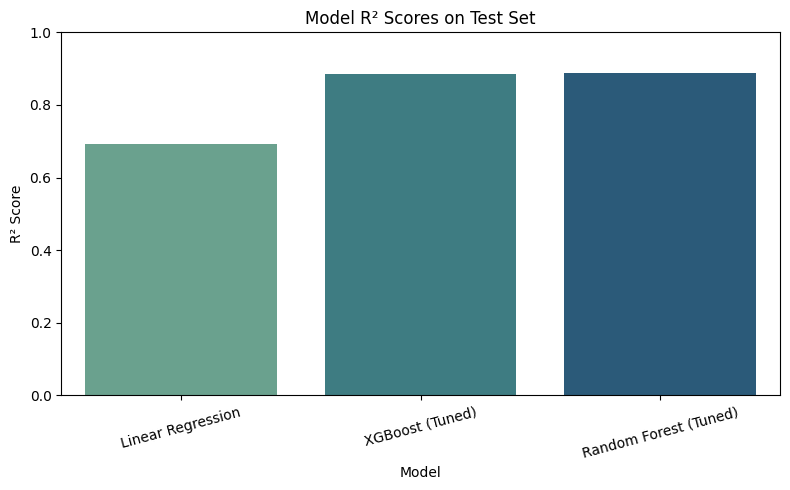

<ipython-input-86-5857ef1c03aa>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE (Test)', data=results_df, palette='crest')


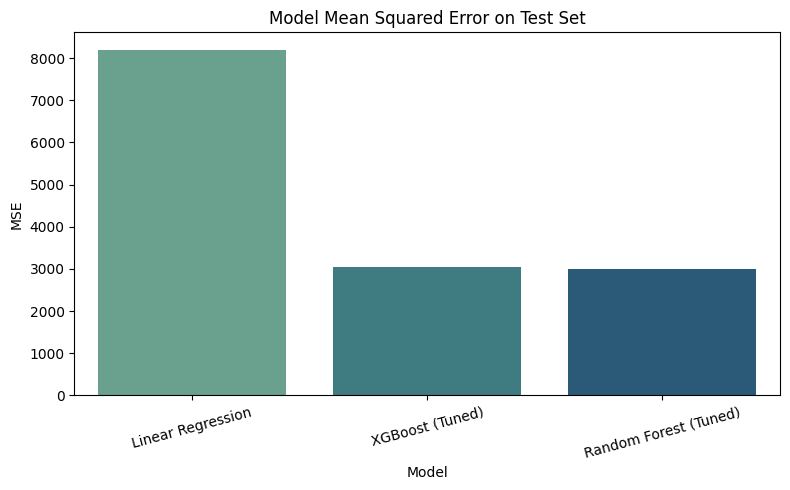

In [ ]:
print("\nSummary of Model Performances:")

# Create a comparison DataFrame with R² and MSE for each model
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost (Tuned)', 'Random Forest (Tuned)'],
    'R² Score (Test)': [
        r2_score(y_test, y_pred_lin_test),
        r2_score(y_test, y_pred_xgb_best_test),
        r2_score(y_test, y_pred_rf_best_test)
    ],
    'MSE (Test)': [
        mean_squared_error(y_test, y_pred_lin_test),
        mean_squared_error(y_test, y_pred_xgb_best_test),
        mean_squared_error(y_test, y_pred_rf_best_test)
    ]
})

# Display numerical comparison
print(results_df)

# Plot R² Score Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R² Score (Test)', data=results_df, palette='crest')
plt.title('Model R² Scores on Test Set')
plt.ylim(0, 1)
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot MSE Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='MSE (Test)', data=results_df, palette='crest')
plt.title('Model Mean Squared Error on Test Set')
plt.ylabel('MSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

To summarize model performance, we visualized the R² scores and Mean Squared Errors (MSE) on the test set for the three models: Linear Regression, Tuned XGBoost, and Tuned Random Forest. Among them, XGBoost delivered the best overall performance, achieving the highest R² score of 0.8867 and the lowest MSE of 3032.62. Random Forest was close behind, with an R² of 0.8547 and an MSE of 3888.37. In contrast, Linear Regression fell behind, with an R² of just 0.6937 and a much higher MSE of 8198.85.

This comparison highlights the value of using non-linear, ensemble-based models for this task. While the linear model was a helpful baseline, it couldn’t fully capture the complex patterns and interactions in the data. Both XGBoost and Random Forest performed better because of their ability to model non-linear relationships and naturally perform some feature selection, leading to stronger generalization. The visualizations make these differences clear and support our final decision on which model to move forward with.

## 6.6 Feature Importance

To better understand how our models make predictions and which variables have the most influence on energy cost, we looked at the feature importance scores for both the tuned Random Forest and XGBoost models. These scores show how much each feature helps reduce prediction error in the model.

Since both Random Forest and XGBoost are tree-based ensemble methods, they naturally provide a way to measure feature relevance. For each model, we plotted the top 15 most important features. This helps us see which inputs are driving predictions the most, and whether certain categorical or engineered features (like device type or cluster labels) are having a bigger impact.

These plots not only make the models more transparent, but they also guide future work—like simplifying the feature set, prioritizing key sensors in a real-world deployment, or designing interventions focused on the factors that matter most.


Plotting Feature Importances...


<ipython-input-87-50998310b4eb>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_top_importances.values, y=rf_top_importances.index, palette='viridis')


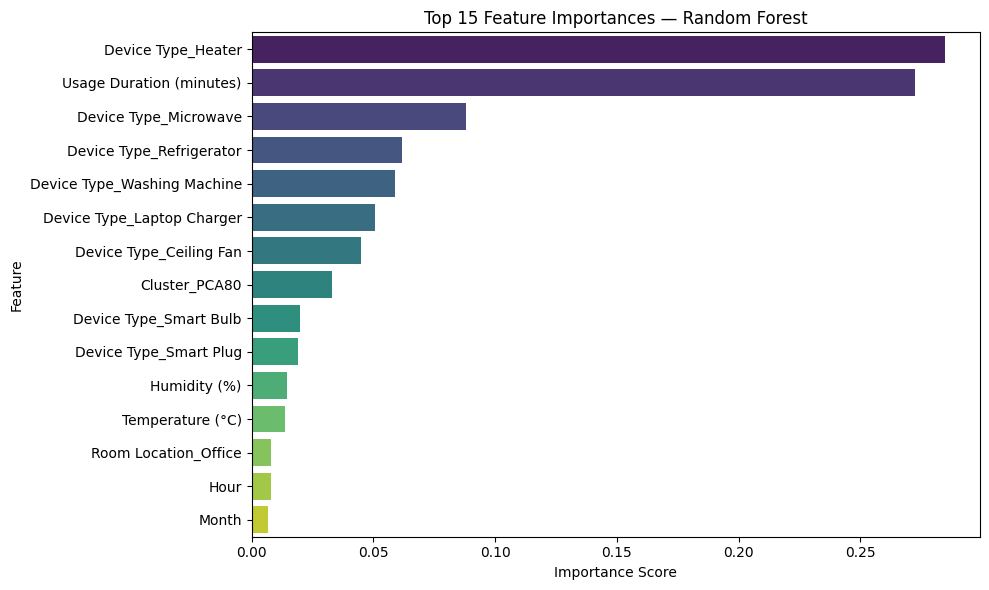

<ipython-input-87-50998310b4eb>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_top_importances.values, y=xgb_top_importances.index, palette='mako')


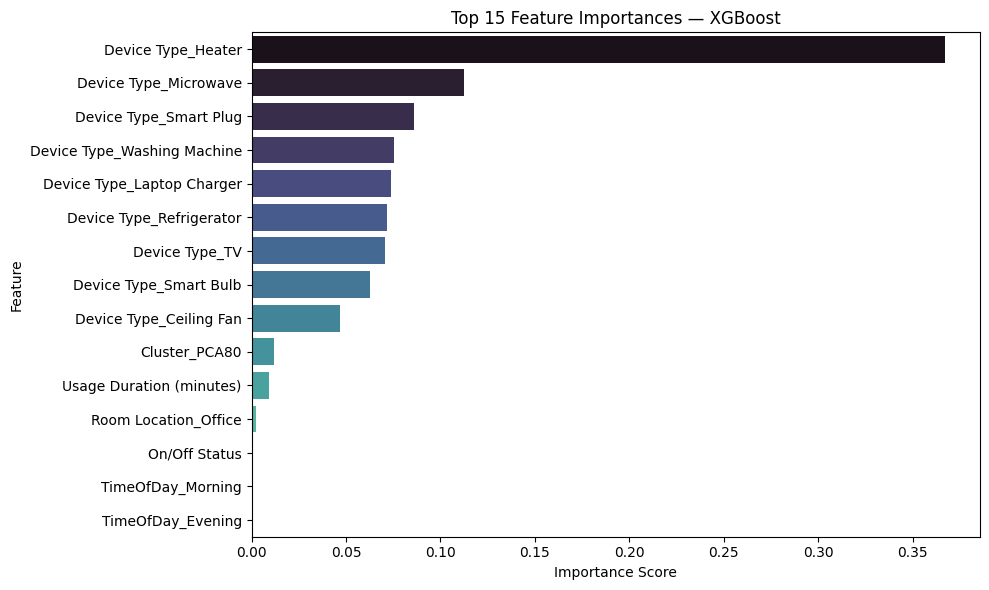

In [ ]:
print("\nPlotting Feature Importances...")

# Extract feature importances from the best tuned Random Forest model
rf_importances = pd.Series(rf_best.feature_importances_, index=X_supervised.columns)
rf_top_importances = rf_importances.sort_values(ascending=False).head(15)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_top_importances.values, y=rf_top_importances.index, palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Extract feature importances from the best tuned XGBoost model
xgb_importances = pd.Series(xgb_best.feature_importances_, index=X_supervised.columns)
xgb_top_importances = xgb_importances.sort_values(ascending=False).head(15)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_top_importances.values, y=xgb_top_importances.index, palette='mako')
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

From the Random Forest results, we see that “Device Type_Heater” and “Usage Duration (minutes)” were by far the most important predictors of energy cost, followed by devices like microwaves and refrigerators. Interestingly, time-based and environmental features like “Hour,” “Temperature,” and “Humidity” played a relatively small role in prediction according to this model.

In the XGBoost feature importance chart, the same trend shows up but even more strongly: “Device Type_Heater” dominates with a very high importance score, and most of the remaining importance is spread across other device-related features. Unlike in Random Forest, usage duration played a much smaller role here. This difference could be because XGBoost handles interactions and nonlinearity differently, putting more emphasis on which device is active rather than when or under what environmental conditions.

Overall, these visualizations reinforce that specific devices—especially high-energy ones like heaters—are the main drivers of variation in energy cost. They also show subtle differences between the models in how they prioritize features, which can help guide future work like simplifying input data or designing smarter control policies for energy management.

# Part 7: Conclusion

**Discussion of Key Takeaways:**

This project showed how effective combining dimensionality reduction, unsupervised learning, and supervised modeling can be when predicting energy costs in a smart home. One of the biggest takeaways is that device type is by far the most important factor when it comes to energy cost. High-energy appliances like heaters and air conditioners were at the top of the feature importance rankings for both Random Forest and XGBoost, while low-power devices like smart bulbs and plugs barely had an impact. Usage duration also turned out to be a big factor, which makes sense since how long a device is running is directly tied to how much energy it uses, especially with high-consumption devices.

Interestingly, environmental and contextual factors, like temperature, humidity, room location, and time of day, didn't end up being as useful for predicting energy cost once we accounted for device type and usage time. This went against some of our initial assumptions, but it really highlights the importance of letting the data guide your feature selection instead of relying solely on intuition.

The best model we ended up with was the tuned XGBoost regressor, which gave us an R² of 0.8867 and the lowest MSE at 3032.62, which was way better than our baseline Linear Regression model (R² of 0.6937). After tuning, Random Forest also did well (R² of 0.8547), but XGBoost definitely had the edge when it came to capturing the more complex, nonlinear relationships in the data. These results show just how valuable ensemble models can be for real-world prediction tasks.

Using unsupervised learning with PCA and KMeans really helped us structure the dataset and boosted model performance. PCA reduced the dimensions while still keeping over 80% of the variance, and KMeans clustering uncovered clear patterns in device usage behavior. Adding the cluster labels as a new feature turned out to be useful, helping the model capture bigger-picture behavior patterns that raw features alone couldn't express.


**Model Implications & Stakeholder Relevance:**

For people involved in smart energy management, like utility companies, home automation developers, or sustainability consultants, our findings point to a few useful applications. First, focusing on high-energy appliances like heaters and air conditioners offers the biggest opportunity for reducing costs, since these devices have the greatest impact on energy use. Second, using device-aware forecasting models could help homeowners make better decisions about when and how to use their devices, especially if those models are connected to systems with dynamic pricing. Finally, clustering users based on their behavior could allow for personalized recommendations, helpful nudges, or alerts that are tailored to different usage patterns, making energy-saving strategies more targeted and effective.



**Dataset limitations:**


*   One major limitation we encountered was the lack of contextual metadata in the Kaggle dataset.
Key information such as the type of household was missing, making it difficult to fully interpret consumption patterns.
Additionally, we noticed anomalies in the data — for instance, the dataset indicated the presence of TVs and refrigerators in bathrooms.
Preliminary research suggests that devices like smart mirrors might be labeled as TVs, but in general, these inconsistencies highlight poor data quality and potential mislabeling of device types.
These issues introduce noise and uncertainty into our analysis and suggest that real-world application would require cleaner, better-documented datasets.



**For future work, we would consider implementing the following:**

1.   Joining with more datasets to increase the complexity of the model.
2. Developing device-specific models that could provide more tailored predictions for high-impact appliances like heaters and air conditioners.
3.  Experimenting with time-series modeling (e.g., LSTMs or temporal ensemble methods) to capture sequential patterns in energy usage that static models like XGBoost may miss.
4. If a more diverse dataset becomes available, testing how well the model generalizes across different household types (e.g., single-family homes vs. apartments) would provide insight into its broader applicability and scalability.

**Overall Experience + Team Reflection:**


1. This project really helped us bring everything together from the course. It wasn’t just about using individual techniques as we had to think through the full process, from cleaning messy data all the way to choosing and evaluating the right models. It made everything we learned feel connected and much more practical.
2. One thing we learned quickly was how important it is to question our assumptions. At first, we expected features like temperature or time of day to play a big role in predicting energy cost. But the models told a different story, and that made us realize how powerful data can be at challenging what we think we know.
3. Continuously iterating on our models taught us that building a strong predictive system isn’t about getting it right on the first try—it’s about testing, tweaking, and improving with each step. As we moved from linear regression to more complex models like Random Forest and XGBoost, we started to understand how each iteration brought new insights and how small changes in tuning or feature selection could lead to big improvements.
4. We also learned not to take the dataset at face value. When we saw refrigerators and TVs showing up in bathrooms, it was a reminder that data can be messy or mislabeled. That pushed us to be more careful and skeptical—and made us appreciate how important it is to validate and clean data before jumping into modeling.
5. One challenge was making sense of our evaluation metrics. It was easy to focus on getting a higher R² score, but we started to think more deeply about what those numbers actually meant in terms of model behavior and real-world usefulness.
6. Working together as a team was a huge part of the project. We learned how to split up the work, share ideas, and help each other through bugs and roadblocks. It made the experience a lot more collaborative and rewarding.
7. We also saw how helpful visualizations can be, not just for presentations, but for understanding what the models were doing. Things like feature importance plots and PCA visualizations helped us make sense of complex relationships in the data and guided our decisions.

